In [ ]:
import os
from dotenv import load_dotenv
from fredapi import Fred
import matplotlib.pyplot as plt
import pandas as pd 

load_dotenv()
fred_api_key = os.getenv("FRED_API_KEY") 

plt.rcParams.update({"axes.grid":True,
                     "grid.color":"black",
                     "grid.alpha":"0.25",
                     "grid.linestyle":"--"})

fred = Fred(api_key=fred_api_key)

## Exercise 1: Loading and summary

Load the data using the Fred API, and calculate summary statistics for the series including mean, standard deviation, minimum, maximum.

Standard deviation is defined by: 

$$
\sqrt(var(X)) = \sqrt{(E(X)^2-E(X^2))} 
$$

In [253]:
fred.search('GDPC1')[['title','units','seasonal_adjustment']].T

series id,GDPC1
title,Real Gross Domestic Product
units,Billions of Chained 2017 Dollars
seasonal_adjustment,Seasonally Adjusted Annual Rate


In [254]:
GDPC1 = fred.get_series('GDPC1')

In [255]:
""" 
Initial solution:

def summary_sats(series: pd.Series):
    mean = series.agg('mean')
    standard_dev = series.agg('std')
    min,max = series.agg(['min','max'])
        
    return mean, standard_dev, min,max 

Problems / inefficiens:
    1. we can utilize the list functionality insidd agg, to make a one liner compbined with the dict.
    2. the dict makes it easy to print
    3. use std instead of standard_dev for naming 

iteration 2: dont even use the dict, seriess aggs gives you a table for free
 """
def summary_sats(series: pd.Series):
    return series.agg(['mean','std','min','max'])

stats = summary_sats(GDPC1)
stats

mean    10323.566706
std      6366.087406
min      2172.432000
max     24055.749000
dtype: float64

## Exercise 2: HP FILTER

Choose a quaterly series and apply the HP Filter

In [256]:
import numpy as np

""" 
My initial attempt:
    removing the iteraiton over t, caused a speedup from 44.7 s to 1.3, crazy

def hp_loss(xx: np.ndarray,tau: np.ndarray, lmbda: float = 1600) -> float:
    acc = 0
    fit_loss = np.sum(np.square(xx-tau))
    for t in range(1,len(tau)-1): 
        acc += ((tau[t+1]-tau[t])-(tau[t]-tau[t-1]))**2
    return float(fit_loss + lmbda*acc)

 """

import numpy as np

def hp_loss(xx: np.ndarray, tau: np.ndarray, lmbda: float = 1600) -> float:
    # 1. Sum of squared deviations (Fit to data)
    fit_loss = np.sum(np.square(xx - tau))
    
    # 2. Sum of squared second differences (Smoothness penalty)
    # np.diff(tau, n=2) calculates: (tau[t+1] - tau[t]) - (tau[t] - tau[t-1])
    second_diff = np.diff(tau, n=2)
    smoothness_loss = lmbda * np.sum(np.square(second_diff))
    
    return float(fit_loss + smoothness_loss)

### Finding the HP filter

Classical optimization problem, where we are interested in the set of values ${\tau_t}^T$, that minimizes the loss.

There is gradient based methods including:

    1. Gradient descend
    2. Netwons method
    3. Qausi Newton (BFGS which essentialy netwons with estimated hessian)

We can also use use non gradient based methods including:

    1. Nelder Mead method
    2. Pattern search (calculate effect of change, move, of no imrpovement stay, and reduce stepsize) 

Since i am not really feeling for differentiating today, and nelder mead seems quite heavy to code up, i am gonna try to do a pattern search

In [ ]:
from typing import Callable, Optional
from copy import deepcopy

# Notes

def pattern_search(hp_loss: Callable[[np.ndarray],float], initial_tau: np.ndarray, step_size: float = 0.00001):
    if initial_tau is None:
        tau = deepcopy(xx)
    else:
        tau = deepcopy(initial_tau)
    current_step_size = step_size
    # Iterate over tau list
        # calc loss for tau up or down,
        # if loss changes < epis, stay, and record did not move
        # else change tau_t with stepsize*change 
    eps = 0.00001 
    best = float("inf") 
    patience = 100
    epoch = 0

    while patience > 0: 
        # print(epoch)
        for t in range(len(tau)):
            t_moved = new_t(hp_loss, step_size, t, tau)
            if (t_moved - tau[t]) < eps:
                continue
            else:
                tau[t] = t_moved

        loss = hp_loss(tau)

        if best > loss:
            best = loss
            #print('Improved with ', loss-best)
        else: 
            step_size = step_size * 0.5
            patience -= 1
        epoch += 1
        #print("loss: ", loss, "best: ", best)
    return tau, best, epoch        

def new_t(hp_loss, step_size, t,tau):
    tau_copy = deepcopy(tau)
    base = hp_loss(tau_copy)
    tau_copy[t] = tau_copy[t] + step_size
    up = hp_loss(tau_copy)
    tau_copy[t] = tau_copy[t] - 2*step_size
    down = hp_loss(tau_copy)
    
    return tau[t] + (np.argmin([down,base,up]) - 1)*step_size # d: -1, b: 0, u: 1

In [ ]:
data = np.log(np.array(GDPC1.values))

loss_function = lambda tau: hp_loss(data, tau)

init_loss = hp_loss(data,data)
print("Initial loss: ", init_loss)
tau, loss, epoch = pattern_search(hp_loss=loss_function,initial_tau=data,step_size=0.0001)


Initial loss:  106.70973554078542


In [260]:
print("FInal loss: ", loss)

FInal loss:  0.39757607413119944


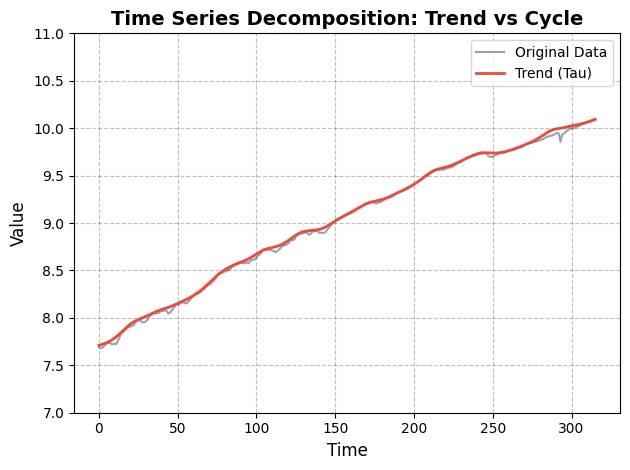

In [263]:
# 2. Plot the Data and Trend (Primary focus)
plt.plot(data, label='Original Data', color='#34495e', alpha=0.5, linewidth=1.5)
plt.plot(tau, label='Trend (Tau)', color='#e74c3c', linewidth=2)

# 3. Plot the Cycle (The 'noise' or residuals)
# We plot it with a dashed line to distinguish it from the main trend

# 4. Annotations and Labels
plt.title('Time Series Decomposition: Trend vs Cycle', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.3) # Reference line at 0
plt.ylim(7, 11)
# 5. Legend and Layout
plt.legend(frameon=True, loc='best')
plt.tight_layout()

plt.show()

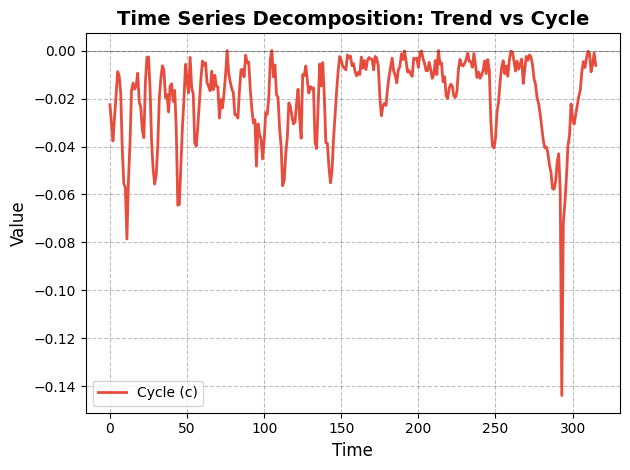

In [262]:
# 2. Plot the Data and Trend (Primary focus)
plt.plot(data-tau, label='Cycle (c)', color='#e74c3c', linewidth=2)

# 3. Plot the Cycle (The 'noise' or residuals)
# We plot it with a dashed line to distinguish it from the main trend

# 4. Annotations and Labels
plt.title('Time Series Decomposition: Trend vs Cycle', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.3) # Reference line at 0

# 5. Legend and Layout
plt.legend(frameon=True, loc='best')
plt.tight_layout()

plt.show()